# 1. Import needed libraries

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os
from PIL import Image
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from glob import glob
#---------------------------------------
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
#---------------------------------------
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten
from tensorflow.keras.optimizers import Adamax
from tensorflow.keras.metrics import Precision, Recall
from tensorflow.keras.preprocessing.image import ImageDataGenerator
#---------------------------------------
import warnings
warnings.filterwarnings("ignore")

# 2. Preprocessing

## 2.1 Load data

In [4]:
tr_df = '/content/drive/MyDrive/MRI Images/Training/'

In [5]:
tr_df

'/content/drive/MyDrive/MRI Images/Training/'

In [6]:
ts_df = '/content/drive/MyDrive/MRI Images/Testing/'

In [7]:
ts_df

'/content/drive/MyDrive/MRI Images/Testing/'

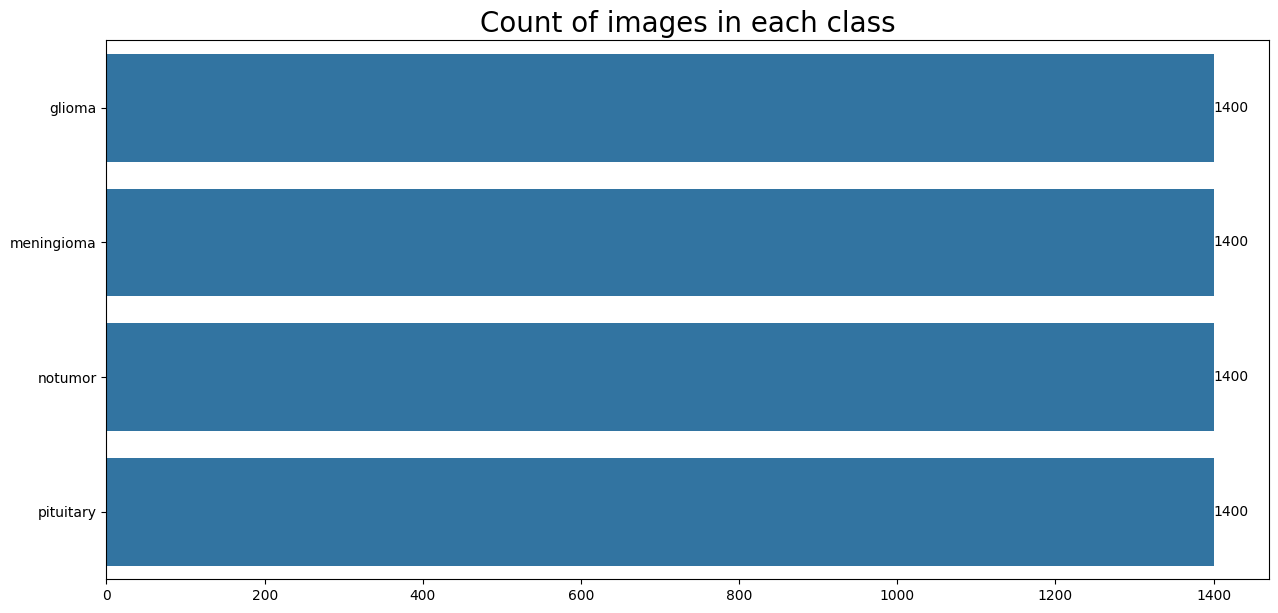

In [8]:
import os
from glob import glob
import pandas as pd

# Create a DataFrame from the directory structure using the tr_df path
image_paths = []
class_names = []

for class_dir in os.listdir(tr_df): # tr_df is the string path from previous cells
    class_path = os.path.join(tr_df, class_dir)
    if os.path.isdir(class_path):
        for img_path in glob(os.path.join(class_path, '*')):
            image_paths.append(img_path)
            class_names.append(class_dir)

# Create a new DataFrame for plotting within this cell
train_df_for_plotting = pd.DataFrame({
    'Class Path': image_paths,
    'Class': class_names
})

# Count of images in each class in train data
plt.figure(figsize=(15,7))
ax = sns.countplot(data=train_df_for_plotting , y=train_df_for_plotting['Class'])

plt.xlabel('')
plt.ylabel('')
plt.title('Count of images in each class', fontsize=20)
ax.bar_label(ax.containers[0])
plt.show()

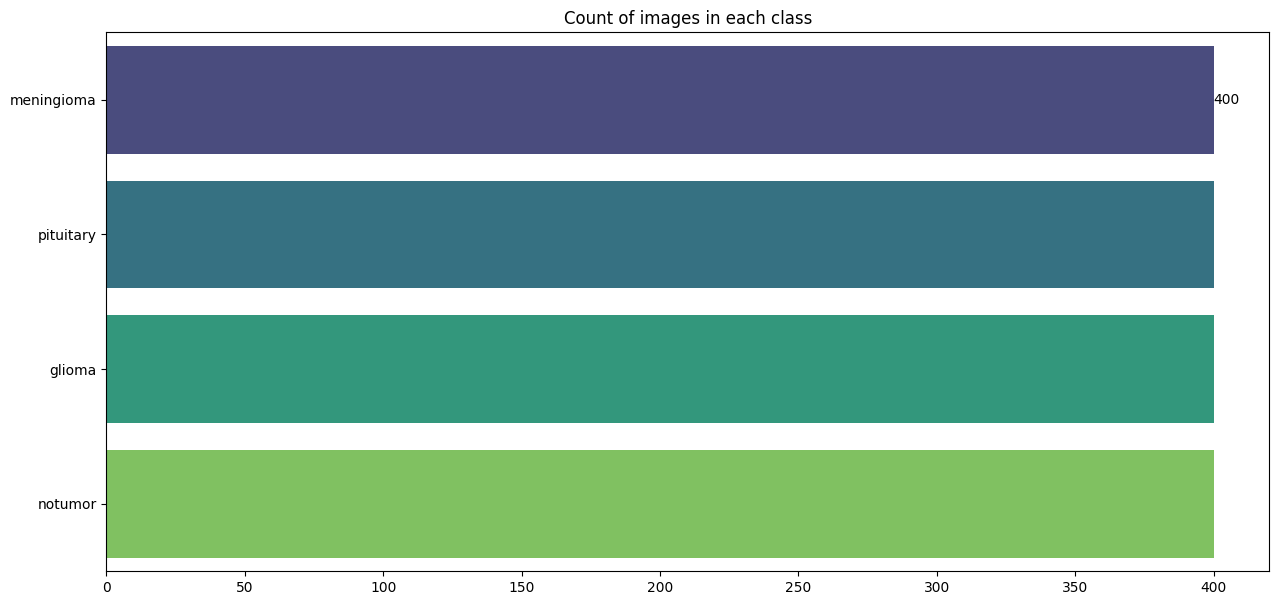

In [9]:
import os
from glob import glob
import pandas as pd

# Create a DataFrame from the directory structure using the ts_df path
image_paths_test = []
class_names_test = []

for class_dir_test in os.listdir(ts_df): # ts_df is the string path from previous cells
    class_path_test = os.path.join(ts_df, class_dir_test)
    if os.path.isdir(class_path_test):
        for img_path_test in glob(os.path.join(class_path_test, '*')):
            image_paths_test.append(img_path_test)
            class_names_test.append(class_dir_test)

# Create a new DataFrame for plotting within this cell
test_df_for_plotting = pd.DataFrame({
    'Class Path': image_paths_test,
    'Class': class_names_test
})

#Count each class in test data
plt.figure(figsize=(15, 7))
ax = sns.countplot(data=test_df_for_plotting, y=test_df_for_plotting['Class'], palette='viridis')

ax.set(xlabel='', ylabel='', title='Count of images in each class')
ax.bar_label(ax.containers[0])

plt.show()

## 2.2 Split data into train, test, valid

In [10]:
import os
from glob import glob
import pandas as pd
from sklearn.model_selection import train_test_split

# Re-create the DataFrame for the test data (from the string path ts_df)
image_paths_test = []
class_names_test = []

for class_dir_test in os.listdir(ts_df):
    class_path_test = os.path.join(ts_df, class_dir_test)
    if os.path.isdir(class_path_test):
        for img_path_test in glob(os.path.join(class_path_test, '*')):
            image_paths_test.append(img_path_test)
            class_names_test.append(class_dir_test)

# Create the actual test DataFrame to be split
test_df_actual = pd.DataFrame({
    'Class Path': image_paths_test,
    'Class': class_names_test
})

# Now perform the split using the DataFrame
valid_df, ts_df = train_test_split(test_df_actual, train_size=0.5, random_state=20, stratify=test_df_actual['Class'])


In [11]:
valid_df

,Class Path,Class
598,/content/drive/MyDrive/MRI Images/Testing/pitu...,pituitary
57,/content/drive/MyDrive/MRI Images/Testing/meni...,meningioma
298,/content/drive/MyDrive/MRI Images/Testing/meni...,meningioma
319,/content/drive/MyDrive/MRI Images/Testing/meni...,meningioma
1308,/content/drive/MyDrive/MRI Images/Testing/notu...,notumor
...,...,...
881,/content/drive/MyDrive/MRI Images/Testing/glio...,glioma
572,/content/drive/MyDrive/MRI Images/Testing/pitu...,pituitary
1592,/content/drive/MyDrive/MRI Images/Testing/notu...,notumor
133,/content/drive/MyDrive/MRI Images/Testing/meni...,meningioma


## 2.3 Data preprocessing

In [12]:
import os
from glob import glob
import pandas as pd
from tensorflow.keras.preprocessing.image import ImageDataGenerator

batch_size = 32
img_size = (299, 299)

_gen = ImageDataGenerator(rescale=1/255,
                          brightness_range=(0.8, 1.2))

ts_gen = ImageDataGenerator(rescale=1/255)

# Create a DataFrame for the training data (from the string path tr_df)
image_paths_train = []
class_names_train = []

for class_dir_train in os.listdir(tr_df): # tr_df is the string path
    class_path_train = os.path.join(tr_df, class_dir_train)
    if os.path.isdir(class_path_train):
        for img_path_train in glob(os.path.join(class_path_train, '*')):
            image_paths_train.append(img_path_train)
            class_names_train.append(class_dir_train)

# Create the actual training DataFrame to be used by flow_from_dataframe
train_df_actual = pd.DataFrame({
    'Class Path': image_paths_train,
    'Class': class_names_train
})

tr_gen = _gen.flow_from_dataframe(train_df_actual, x_col='Class Path',
                                  y_col='Class', batch_size=batch_size,
                                  target_size=img_size)

valid_gen = _gen.flow_from_dataframe(valid_df, x_col='Class Path',
                                     y_col='Class', batch_size=batch_size,
                                     target_size=img_size)

ts_gen = ts_gen.flow_from_dataframe(ts_df, x_col='Class Path',
                                  y_col='Class', batch_size=16,
                                  target_size=img_size, shuffle=False)

Found 5600 validated image filenames belonging to 4 classes.
Found 800 validated image filenames belonging to 4 classes.
Found 800 validated image filenames belonging to 4 classes.


## 2.4 Getting samples from data

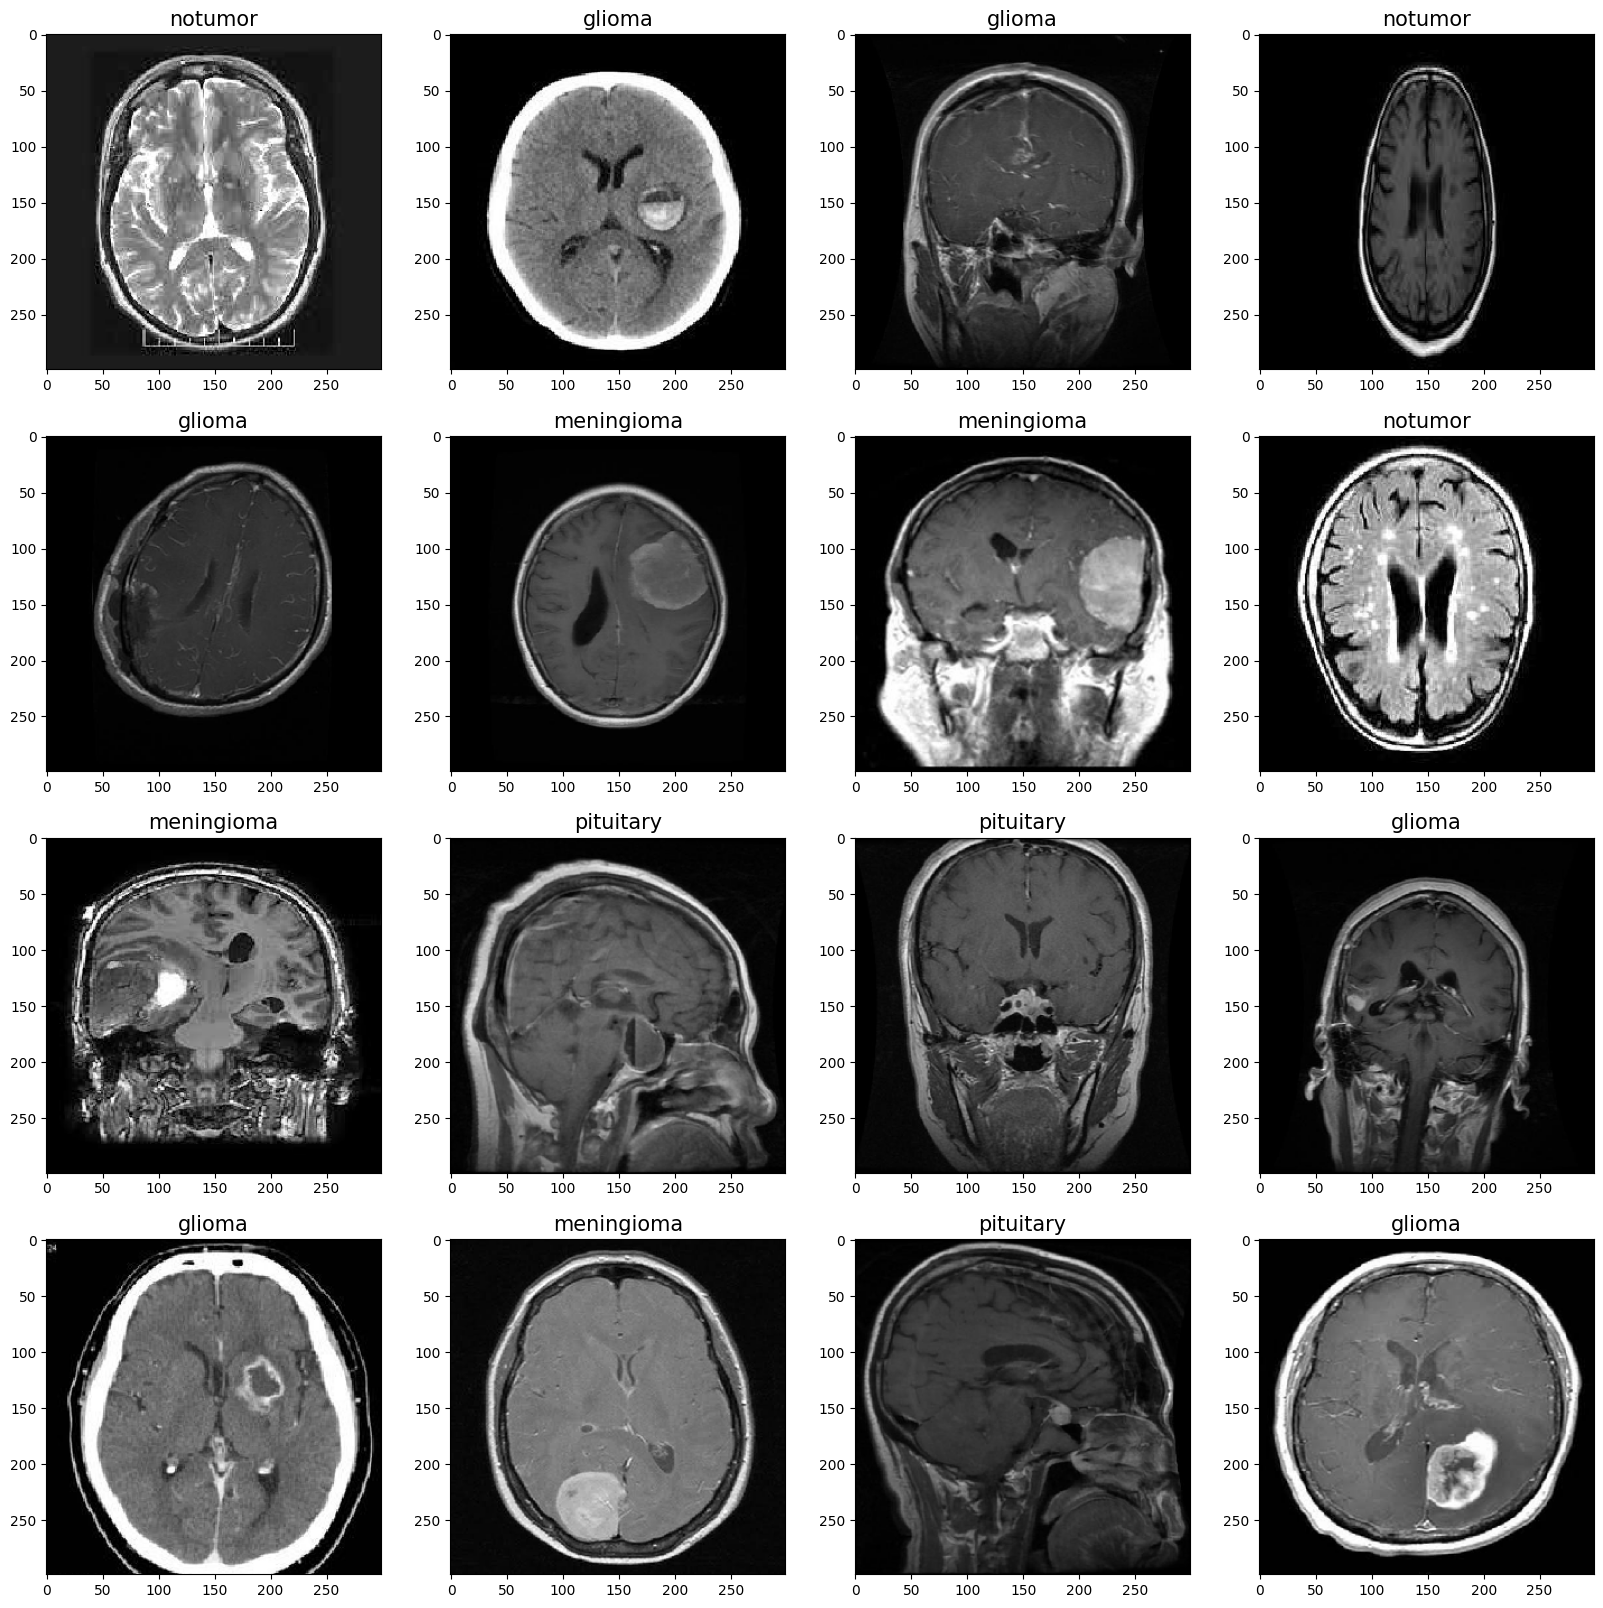

In [13]:
class_dict = tr_gen.class_indices
classes = list(class_dict.keys())
images, labels = next(ts_gen)

plt.figure(figsize=(20, 20))

for i, (image, label) in enumerate(zip(images, labels)):
    plt.subplot(4,4, i + 1)
    plt.imshow(image)
    class_name = classes[np.argmax(label)]
    plt.title(class_name, color='k', fontsize=15)

plt.show()

# 3. Building Deep Learning Model

In [14]:
img_shape=(299,299,3)
base_model = tf.keras.applications.Xception(include_top= False, weights= "imagenet",
                            input_shape= img_shape, pooling= 'max')

# for layer in base_model.layers:
#     layer.trainable = False

model = Sequential([
    base_model,
    Flatten(),
    Dropout(rate= 0.3),
    Dense(128, activation= 'relu'),
    Dropout(rate= 0.25),
    Dense(4, activation= 'softmax')
])

model.compile(Adamax(learning_rate= 0.001),
              loss= 'categorical_crossentropy',
              metrics= ['accuracy',
                        Precision(),
                        Recall()])

model.summary()

83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ xception (Functional)           │ (None, 2048)           │    20,861,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,124,268 (80.58 MB)

 Trainable params: 21,069,740 (80.37 MB)

 Non-trainable params: 54,528 (213.00 KB)

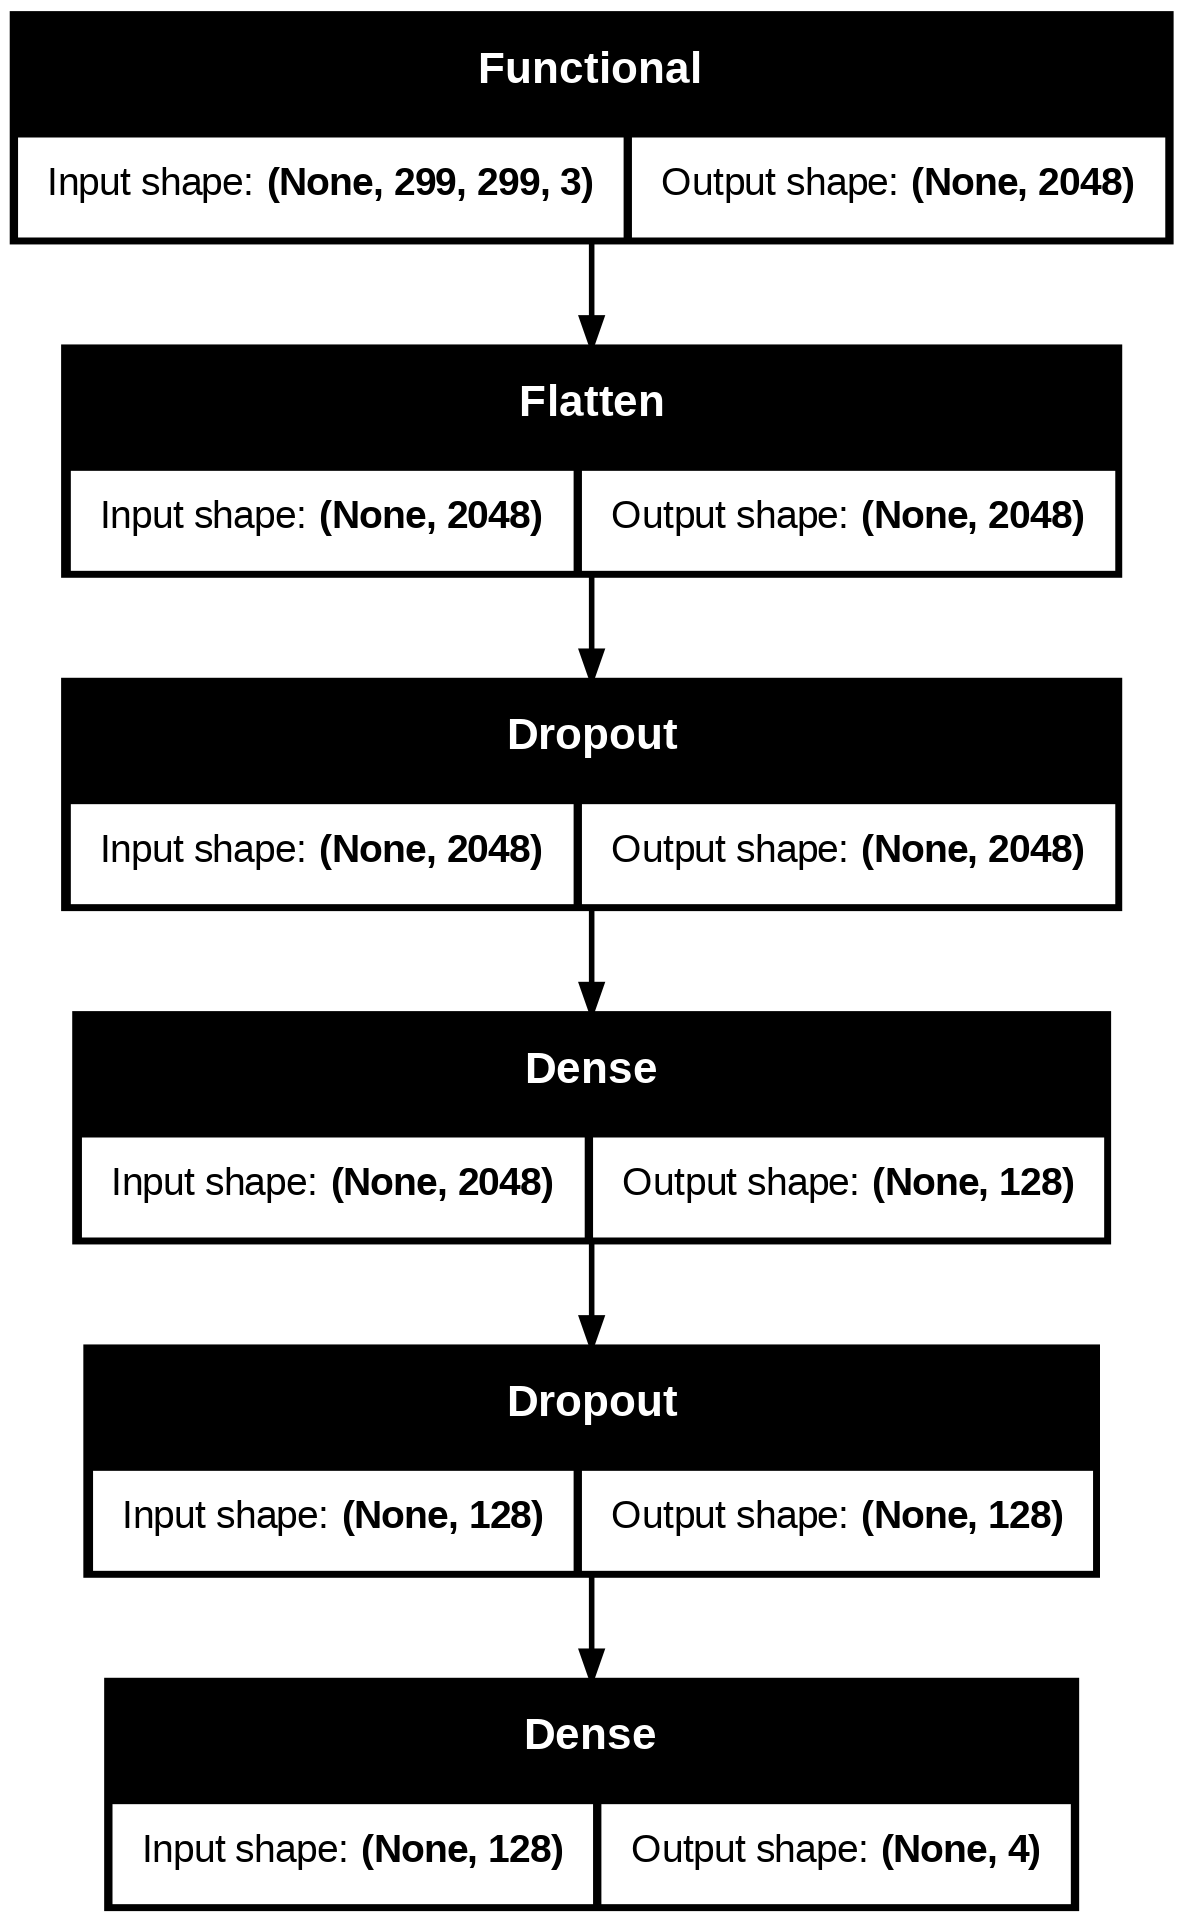

In [15]:
tf.keras.utils.plot_model(model, show_shapes=True)

# 4. Training

In [16]:
hist = model.fit(tr_gen,
                 epochs=10,
                 validation_data=valid_gen,
                 shuffle= False)

Epoch 1/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 1908s 10s/step - accuracy: 0.8537 - loss: 0.3978 - precision: 0.9168 - recall: 0.8064 - val_accuracy: 0.9250 - val_loss: 0.2471 - val_precision: 0.9347 - val_recall: 0.9125
Epoch 2/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 185s 1s/step - accuracy: 0.9805 - loss: 0.0615 - precision: 0.9814 - recall: 0.9795 - val_accuracy: 0.8763 - val_loss: 0.4767 - val_precision: 0.8805 - val_recall: 0.8750
Epoch 3/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 193s 1s/step - accuracy: 0.9896 - loss: 0.0368 - precision: 0.9896 - recall: 0.9884 - val_accuracy: 0.9513 - val_loss: 0.2603 - val_precision: 0.9524 - val_recall: 0.9513
Epoch 4/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 193s 1s/step - accuracy: 0.9941 - loss: 0.0200 - precision: 0.9945 - recall: 0.9939 - val_accuracy: 0.9550 - val_loss: 0.2878 - val_precision: 0.9549 - val_recall: 0.9538
Epoch 5/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 192s 1s/step - accuracy: 0.9948 - loss: 0.0146 - precision: 0.9950 - recall: 0.9946 - val_accuracy: 0.9525 - val_l

In [17]:
hist.history.keys()

dict_keys(['accuracy', 'loss', 'precision', 'recall', 'val_accuracy', 'val_loss', 'val_precision', 'val_recall'])

## 4.1 Visualize model performance

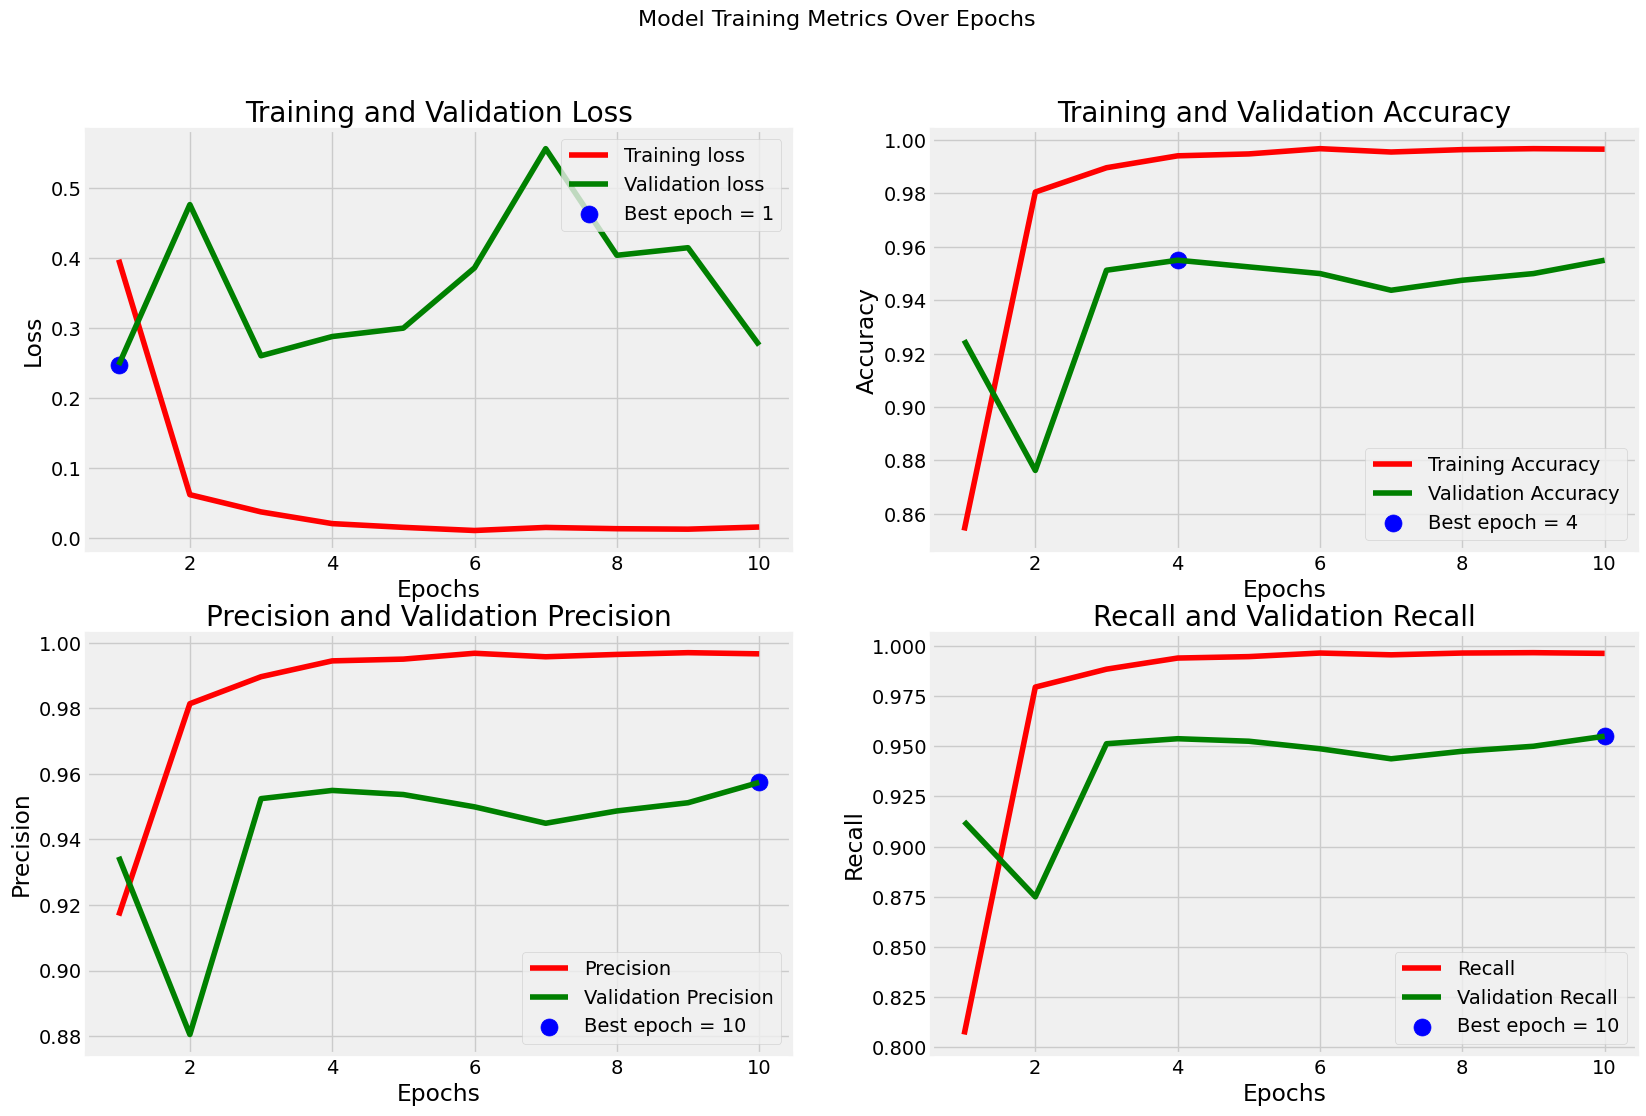

In [18]:
tr_acc = hist.history['accuracy']
tr_loss = hist.history['loss']
tr_per = hist.history['precision']
tr_recall = hist.history['recall']
val_acc = hist.history['val_accuracy']
val_loss = hist.history['val_loss']
val_per = hist.history['val_precision']
val_recall = hist.history['val_recall']

index_loss = np.argmin(val_loss)
val_lowest = val_loss[index_loss]
index_acc = np.argmax(val_acc)
acc_highest = val_acc[index_acc]
index_precision = np.argmax(val_per)
per_highest = val_per[index_precision]
index_recall = np.argmax(val_recall)
recall_highest = val_recall[index_recall]

Epochs = [i + 1 for i in range(len(tr_acc))]
loss_label = f'Best epoch = {str(index_loss + 1)}'
acc_label = f'Best epoch = {str(index_acc + 1)}'
per_label = f'Best epoch = {str(index_precision + 1)}'
recall_label = f'Best epoch = {str(index_recall + 1)}'


plt.figure(figsize=(20, 12))
plt.style.use('fivethirtyeight')


plt.subplot(2, 2, 1)
plt.plot(Epochs, tr_loss, 'r', label='Training loss')
plt.plot(Epochs, val_loss, 'g', label='Validation loss')
plt.scatter(index_loss + 1, val_lowest, s=150, c='blue', label=loss_label)
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(2, 2, 2)
plt.plot(Epochs, tr_acc, 'r', label='Training Accuracy')
plt.plot(Epochs, val_acc, 'g', label='Validation Accuracy')
plt.scatter(index_acc + 1, acc_highest, s=150, c='blue', label=acc_label)
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(2, 2, 3)
plt.plot(Epochs, tr_per, 'r', label='Precision')
plt.plot(Epochs, val_per, 'g', label='Validation Precision')
plt.scatter(index_precision + 1, per_highest, s=150, c='blue', label=per_label)
plt.title('Precision and Validation Precision')
plt.xlabel('Epochs')
plt.ylabel('Precision')
plt.legend()
plt.grid(True)

plt.subplot(2, 2, 4)
plt.plot(Epochs, tr_recall, 'r', label='Recall')
plt.plot(Epochs, val_recall, 'g', label='Validation Recall')
plt.scatter(index_recall + 1, recall_highest, s=150, c='blue', label=recall_label)
plt.title('Recall and Validation Recall')
plt.xlabel('Epochs')
plt.ylabel('Recall')
plt.legend()
plt.grid(True)

plt.suptitle('Model Training Metrics Over Epochs', fontsize=16)
plt.show()

# 5. Testing and Evaluation

## 5.1 Evaluate

In [19]:
train_score = model.evaluate(tr_gen, verbose=1)
valid_score = model.evaluate(valid_gen, verbose=1)
test_score = model.evaluate(ts_gen, verbose=1)

print(f"Train Loss: {train_score[0]:.4f}")
print(f"Train Accuracy: {train_score[1]*100:.2f}%")
print('-' * 20)
print(f"Validation Loss: {valid_score[0]:.4f}")
print(f"Validation Accuracy: {valid_score[1]*100:.2f}%")
print('-' * 20)
print(f"Test Loss: {test_score[0]:.4f}")
print(f"Test Accuracy: {test_score[1]*100:.2f}%")


175/175 ━━━━━━━━━━━━━━━━━━━━ 46s 264ms/step - accuracy: 0.9996 - loss: 0.0017 - precision: 0.9996 - recall: 0.9995
25/25 ━━━━━━━━━━━━━━━━━━━━ 7s 262ms/step - accuracy: 0.9525 - loss: 0.2957 - precision: 0.9537 - recall: 0.9525
50/50 ━━━━━━━━━━━━━━━━━━━━ 199s 4s/step - accuracy: 0.9588 - loss: 0.2434 - precision: 0.9599 - recall: 0.9588
Train Loss: 0.0017
Train Accuracy: 99.96%
--------------------
Validation Loss: 0.2957
Validation Accuracy: 95.25%
--------------------
Test Loss: 0.2434
Test Accuracy: 95.88%


In [20]:
preds = model.predict(ts_gen)
y_pred = np.argmax(preds, axis=1)

50/50 ━━━━━━━━━━━━━━━━━━━━ 20s 115ms/step


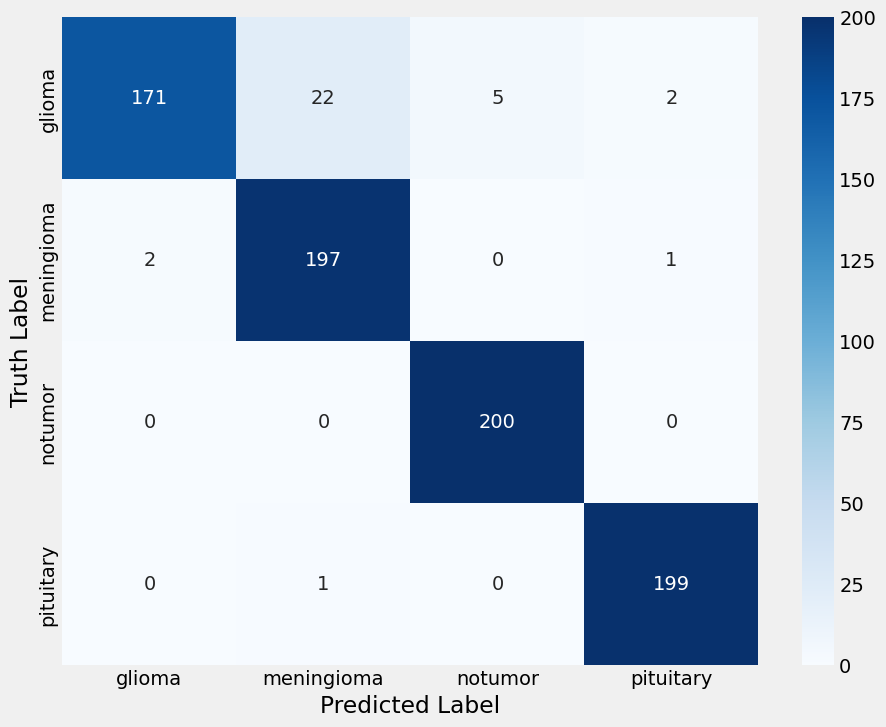

In [21]:
cm = confusion_matrix(ts_gen.classes, y_pred)
labels = list(class_dict.keys())
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted Label')
plt.ylabel('Truth Label')
plt.show()

In [22]:
clr = classification_report(ts_gen.classes, y_pred)
print(clr)

              precision    recall  f1-score   support

           0       0.99      0.85      0.92       200
           1       0.90      0.98      0.94       200
           2       0.98      1.00      0.99       200
           3       0.99      0.99      0.99       200

    accuracy                           0.96       800
   macro avg       0.96      0.96      0.96       800
weighted avg       0.96      0.96      0.96       800



## 5.2 Testing

In [36]:
def predict(img_path):
    import numpy as np
    import matplotlib.pyplot as plt
    from PIL import Image
    label = list(class_dict.keys())
    plt.figure(figsize=(12, 12))
    img = Image.open(img_path).convert('RGB')
    resized_img = img.resize((299, 299))
    img = np.asarray(resized_img)
    img = np.expand_dims(img, axis=0)
    img = img / 255
    predictions = model.predict(img)
    probs = list(predictions[0])
    labels = label
    plt.subplot(2, 1, 1)
    plt.imshow(resized_img)
    plt.subplot(2, 1, 2)
    bars = plt.barh(labels, probs)
    plt.xlabel('Probability', fontsize=15)
    ax = plt.gca()
    ax.bar_label(bars, fmt = '%.2f')
    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 25s 25s/step


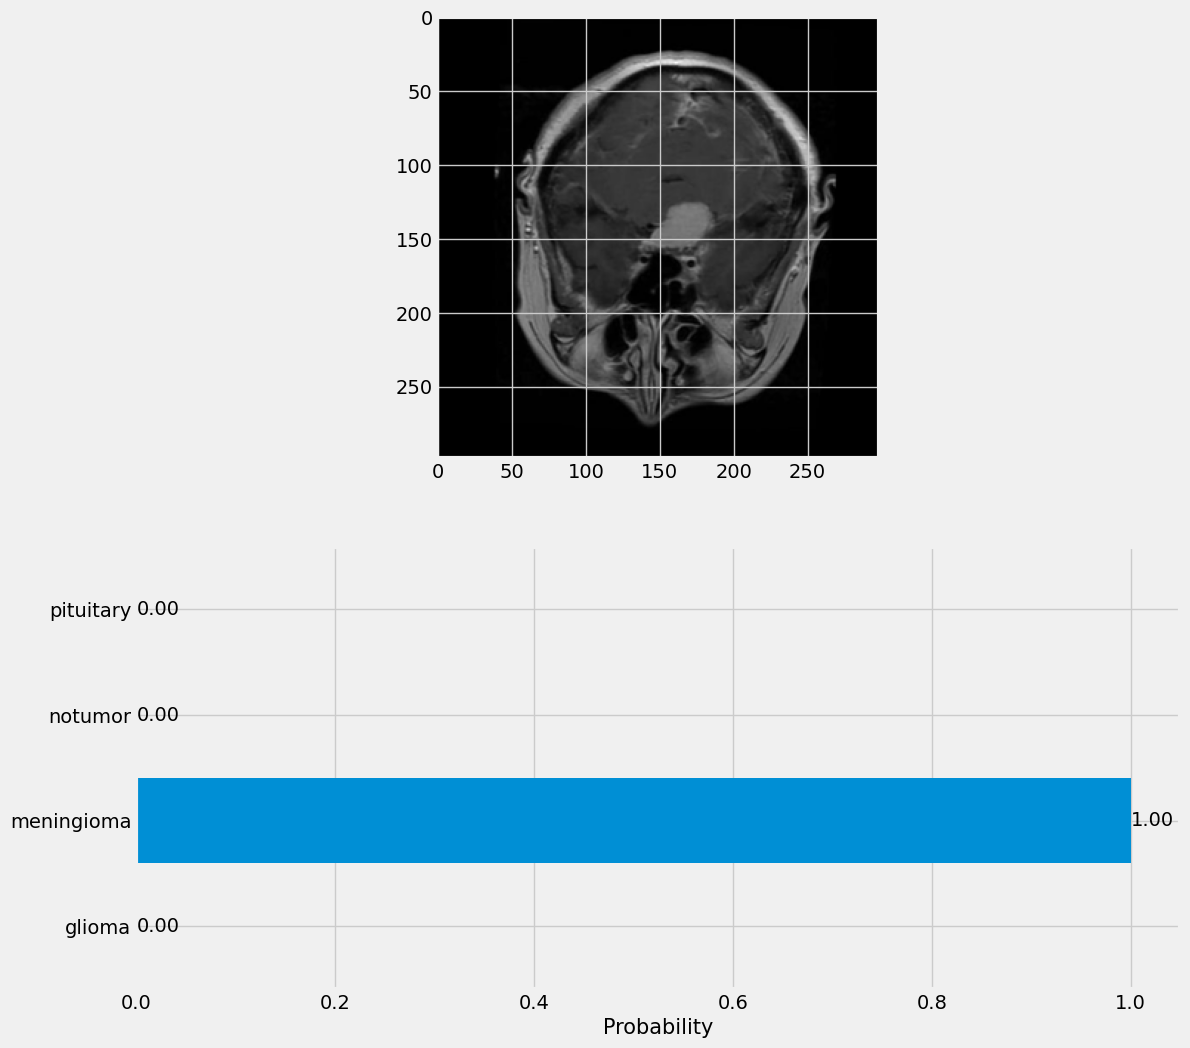

In [26]:
predict('/content/drive/MyDrive/MRI Images/Testing/meningioma/Te-aug-me_16.jpg')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step


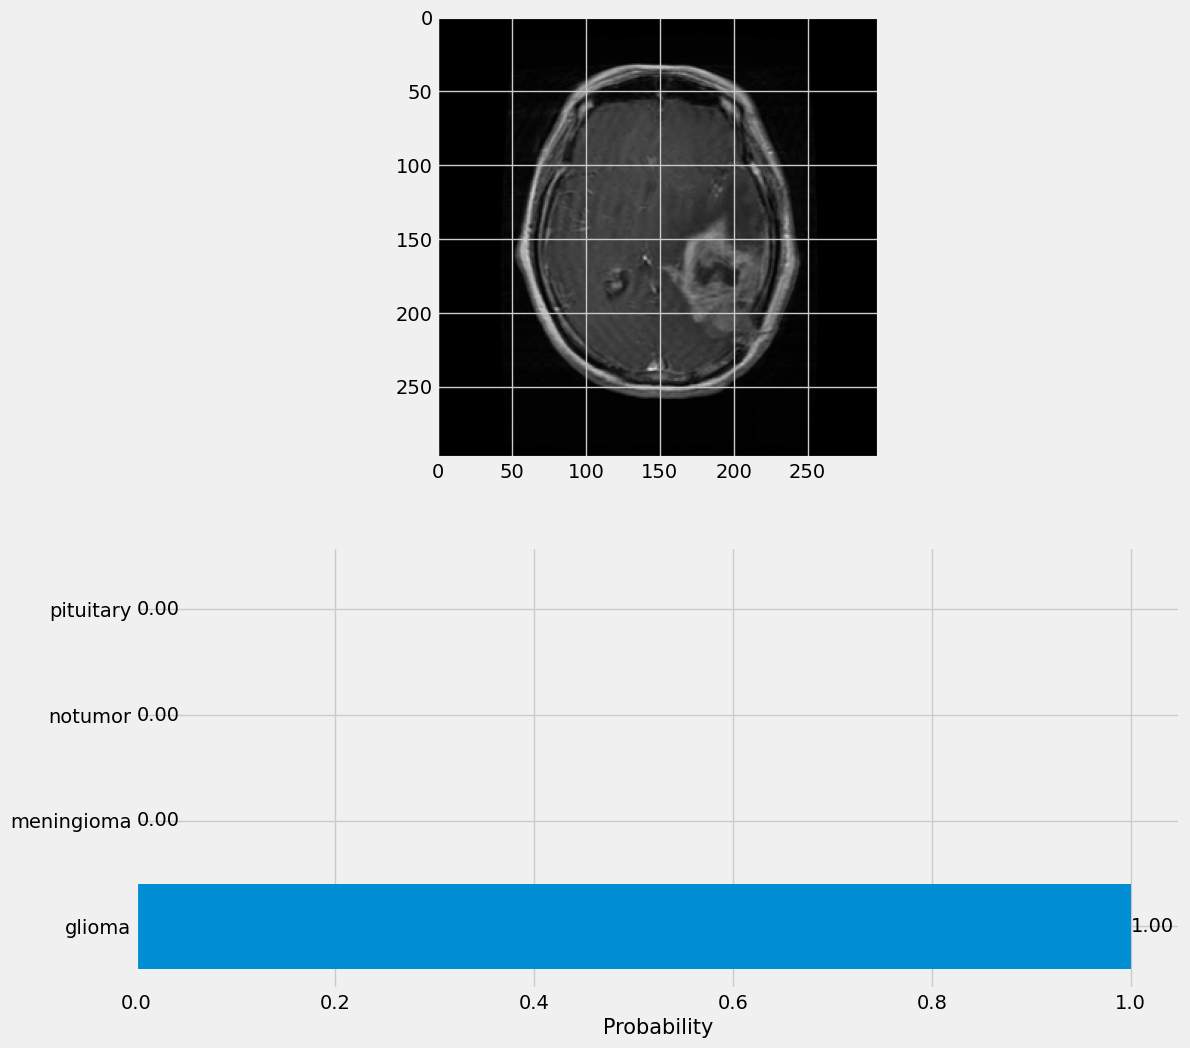

In [29]:
predict('/content/drive/MyDrive/MRI Images/Testing/glioma/Te-gl_12.jpg')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step


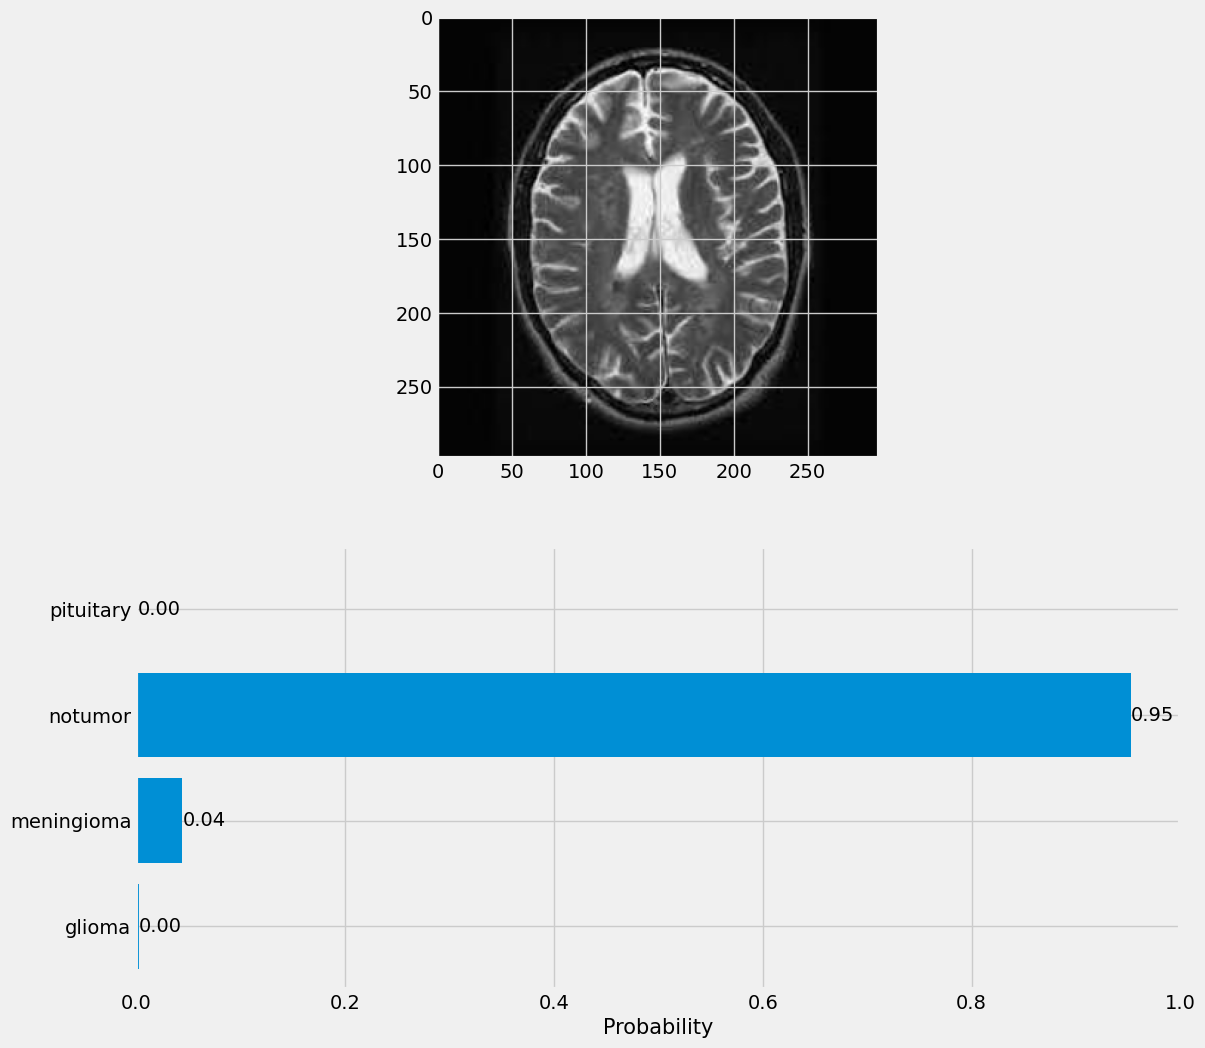

In [30]:
predict('/content/drive/MyDrive/MRI Images/Testing/notumor/Te-no_145.jpg')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step


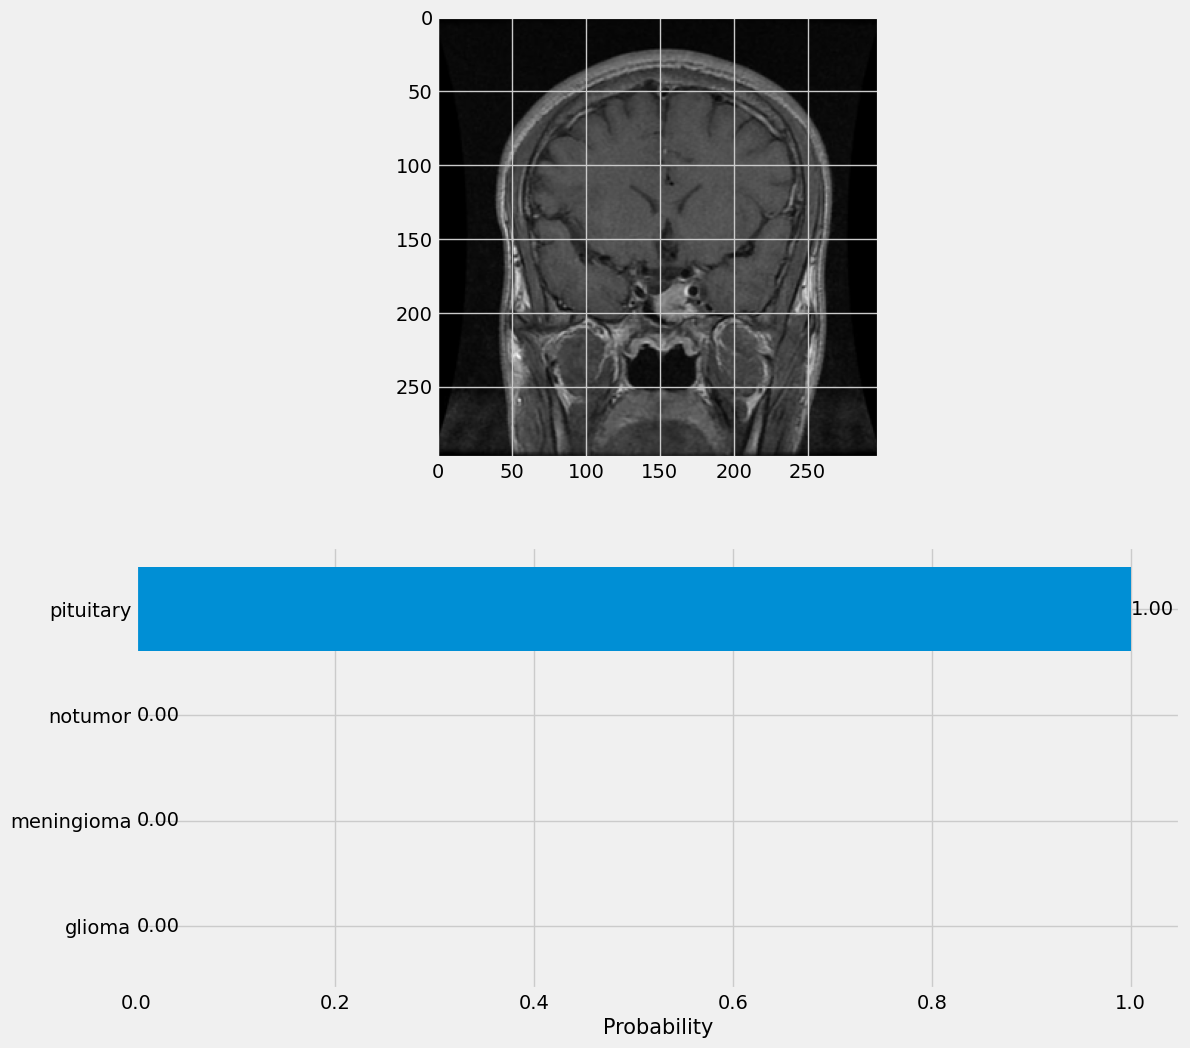

In [37]:
predict('/content/drive/MyDrive/MRI Images/Testing/pituitary/Te-pi_354.jpg')

In [27]:
# Save the model in H5 format
model.save('model.h5')
print("model.h5")

model.h5
